### Modules and Libraries

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import os
import hashlib
from PIL import Image
import numpy as np
import random
from torch.utils.data import Subset
import copy

### Hardware and Project Configs

In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# parallel processing fuer schnelleres trainieren des models
NUM_WORKERS = 0

# hyperparameters fuer lokales setup 
BATCH_SIZE = 64
IMG_SIZE = 100 
EPOCHS = 20
LEARNING_RATE = 1e-3
NUM_CLASSES = 33

# pfade der bilder
TRAIN_DIR = "Fruits/train/train"   
TEST_DIR = "Fruits/test/test"

print(f"configs fuer diesen run:\nworkers: {NUM_WORKERS}  | batch size: {BATCH_SIZE} | on device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

configs fuer diesen run:
workers: 0  | batch size: 64 | on device: AMD Radeon RX 7700 XT


### Data Engineering: Integrity check

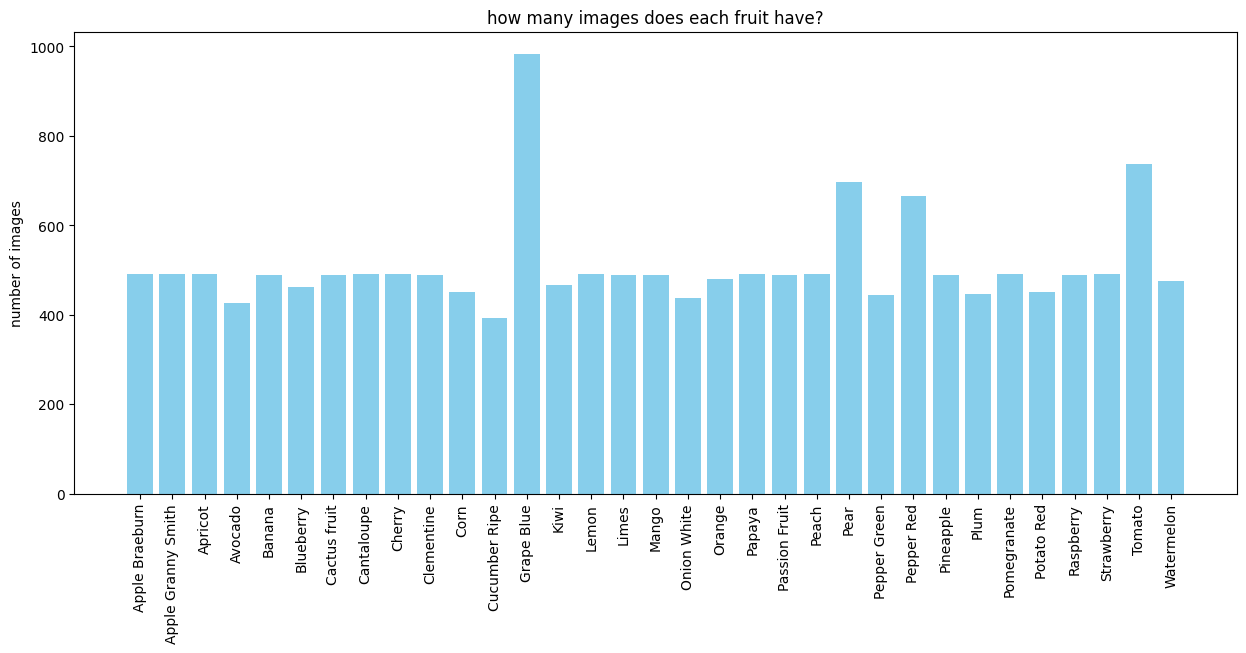

In [5]:
# diese listen speichern daten fuer die plots
fruit_names = []
fruit_counts = []


all_items = os.listdir(TRAIN_DIR)                   # extrahiere namen der folder

for item_name in all_items:                         # loop through every item found                      

    item_path = os.path.join(TRAIN_DIR, item_name)  # create the full path to the item
    

    if os.path.isdir(item_path):                    # erst checken ob es sich um ein directory handelt
        files_inside = os.listdir(item_path)        # alle files auflisten
        number_of_images = len(files_inside)        # count how many files are in there
        
        fruit_names.append(item_name)               # append namen in die liste
        fruit_counts.append(number_of_images)       # append count in die liste


plt.figure(figsize=(15, 6))                         # erstellt die figure fuer den plot mit (width=15, height=6)
plt.bar(fruit_names, fruit_counts, color='skyblue') 
plt.title("how many images does each fruit have?")  
plt.ylabel("number of images")                     
plt.xticks(rotation=90)                             
plt.show()

In [ ]:
plt.figure(figsize=(10, 10))                        # create a new figure for the images
for i in range(9):
    random_fruit = random.choice(fruit_names)       # pick a random fruit name from our list
    fruit_folder = os.path.join(TRAIN_DIR, random_fruit)
    files_in_fruit_folder = os.listdir(fruit_folder)
    random_file = random.choice(files_in_fruit_folder)
    image_location = os.path.join(fruit_folder, random_file)
    
    img = Image.open(image_location)
    
   
    plt.subplot(3, 3, i + 1)                        # sublot fuer ein 3x3 feld
                                                    # i + 1 weil matplotlib erst mit 1 beginnt, nicht mit 0 (wegen der range() function)
    plt.imshow(img)
    plt.title(random_fruit)
    plt.axis('off')


plt.show()

### Data Pipeline and Augmentation

In [ ]:
# datenverarbeitungs- und augmentationsblock
train_transform = transforms.Compose([                                  # 1. positionale transformationen
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.5, 1.0)), 
    transforms.RandomAffine(degrees=45, translate=(0.2, 0.2)), 
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5), 

    transforms.ColorJitter(                                             # 2. licht und farbe
        brightness=0.4, 
        contrast=0.4, 
        saturation=0.4, 
        hue=0.05 
    ),
    transforms.RandomGrayscale(p=0.1),                                  # 3. 10% der farbe auf greyscale um konturen zu lernen      

    transforms.ToTensor(),                                              # 4. Wandelt Bilder in einen Tensor (mehrdimensionale Matrix) um
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))              #    und normalisiert diese auf -1 bis 1 für Stabileres Training
])


val_transform = transforms.Compose([                                    # validation ohne transformationen composen
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [14]:
raw_dataset = datasets.ImageFolder(TRAIN_DIR)   # wir laden den ordner einmal komplett, nur um zu zählen, wie viele bilder da sind

count_train = int(0.8 * len(raw_dataset))       # berechne die anzahl: 80% für training, der rest für validierung
count_val = len(raw_dataset) - count_train



train_ids, val_ids = random_split(range(len(raw_dataset)), [count_train, count_val])    # wir erstellen zwei listen mit zufälligen id-nummern (z.b. 1, 5, 99... und 2, 3, 10...)

dataset_with_noise = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)         # transformierte bilder 
dataset_clean = datasets.ImageFolder(TRAIN_DIR, transform=val_transform)                # cleane bilder

final_train_subset = Subset(dataset_with_noise, train_ids)
final_val_subset = Subset(dataset_clean, val_ids)


train_loader = DataLoader(final_train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory = True) # der loader fuettert das modell haeppchenweise (batch_size) mit bildern
val_loader = DataLoader(final_val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory = True)


class_names = raw_dataset.classes                                                       # klassennamen speichern (apfel, banane, etc.)

### Model Architecture

In [ ]:
class FruitCNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        # 1. feature extraction (sehen)
        self.features = nn.Sequential(
            # block 1: kanten finden
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # eingang: 3 farben -> 32 merkmale
            nn.BatchNorm2d(32),                          # stabilisiert das lernen
            nn.ReLU(),                                   # aktiviert neuronen
            nn.MaxPool2d(2),                             # bild verkleinern (100 -> 50px)

            # block 2: formen finden
            nn.Conv2d(32, 64, kernel_size=3, padding=1), # 32 -> 64 merkmale
            nn.BatchNorm2d(64),                          # stabilisierung
            nn.ReLU(),                                   # aktivierung
            nn.MaxPool2d(2),                             # verkleinern (50 -> 25px)

            # block 3: texturen finden
            nn.Conv2d(64, 128, kernel_size=3, padding=1),# 64 -> 128 merkmale
            nn.BatchNorm2d(128),                         # stabilisierung
            nn.ReLU(),                                   # aktivierung
            nn.MaxPool2d(2)                              # verkleinern (25 -> 12px)
        )
        
        # 2. entscheiden (classifier)
        # wir haben jetzt 128 merkmale * 12 * 12 pixel größe
        self.flatten_dim = 128 * 12 * 12
        
        self.classifier = nn.Sequential(
            nn.Flatten(),                     # alles in eine lange reihe schreiben
            nn.Linear(self.flatten_dim, 512), # erste denkschicht
            nn.ReLU(),                        # aktivierung
            nn.Dropout(0.5),                  # 50% vergessen (gegen overfitting!)
            nn.Linear(512, NUM_CLASSES)       # ausgabe: unsere früchte
        )

    def forward(self, x):
        x = self.features(x)   # erst gucken
        x = self.classifier(x) # dann entscheiden
        return x

# modell erstellen und auf die grafikkarte schieben
model = FruitCNN().to(DEVICE)

### Training Loop

In [ ]:
# werkzeuge
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

# "brems-assistent" (scheduler)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

# listen für die kurven
train_losses = []
val_losses = []

# variablen für den rekord-halter
best_val_loss = float('inf')                          # am anfang ist unendlich der "beste" wert
best_model_wts = copy.deepcopy(model.state_dict()) # wir merken uns den start-zustand



for epoch in range(EPOCHS):
    
    #1. lernen (training)
    model.train()                                                   # lern-modus an
    running_loss = 0.0
    
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)       # ab auf die grafikkarte
        
        optimizer.zero_grad()                                       # gedaechtnis löschen
        outputs = model(images)                                     # raten
        loss = criterion(outputs, labels)                           # fehler berechnen
        loss.backward()                                             # lernen
        optimizer.step()                                            # verbessern
        
        running_loss += loss.item()                                 # fehler merken

    # 2. pruefen (validierung)
    model.eval()                                                    # lern-modus aus (nur pruefen)
    val_running_loss = 0.0 
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            
            outputs = model(images)                                 # raten
            
            # fehler auch bei der pruefung berechnen
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()
            
            # genauigkeit berechnen
            _, preds = torch.max(outputs, 1)                        # beste antwort wählen
            correct += (preds == labels).sum().item()               # richtige zählen
            total += labels.size(0)                                 # anzahl bilder zählen

    # --- statistik ---
    avg_train_loss = running_loss / len(train_loader)               # durchschnitts-fehler train
    avg_val_loss = val_running_loss / len(val_loader)               # durchschnitts-fehler val
    
    acc = 100 * correct / total                                     # genauigkeit in %
    
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    
    # NEU: scheduler fragen (ohne verbose)
    scheduler.step(avg_val_loss)
    
    # aktuelle lernrate abfragen (damit wir sehen, ob gebremst wurde)
    current_lr = optimizer.param_groups[0]['lr']
    
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_wts = copy.deepcopy(model.state_dict())          # bestes wissen sichern

    # hier zeigen wir jetzt auch die 'LR' (lernrate) an
    print(f"Runde {epoch+1}: Train={avg_train_loss:.4f} | Val={avg_val_loss:.4f} | Acc={acc:.1f}% | LR={current_lr:.6f}")


# am ende laden wir den besten zustand zurück
model.load_state_dict(best_model_wts)



Runde 1: Train=2.5383 | Val=1.6708 | Acc=36.9% | LR=0.001000
Runde 2: Train=1.9597 | Val=1.4916 | Acc=47.8% | LR=0.001000
Runde 3: Train=1.8154 | Val=2.8107 | Acc=34.6% | LR=0.001000
Runde 4: Train=1.6807 | Val=1.2069 | Acc=61.5% | LR=0.001000
Runde 5: Train=1.6089 | Val=1.6465 | Acc=54.9% | LR=0.001000
Runde 6: Train=1.4855 | Val=1.5142 | Acc=59.8% | LR=0.001000
Runde 7: Train=1.4150 | Val=0.9731 | Acc=68.3% | LR=0.001000
Runde 8: Train=1.3488 | Val=2.2186 | Acc=43.7% | LR=0.001000
Runde 9: Train=1.2780 | Val=1.5640 | Acc=56.1% | LR=0.001000
Runde 10: Train=1.2317 | Val=1.7632 | Acc=55.9% | LR=0.000500
Runde 11: Train=1.0646 | Val=1.3956 | Acc=65.2% | LR=0.000500
Runde 12: Train=1.0371 | Val=2.1679 | Acc=52.4% | LR=0.000500
Runde 13: Train=1.0344 | Val=0.9755 | Acc=68.1% | LR=0.000250
Runde 14: Train=0.9498 | Val=1.6409 | Acc=57.0% | LR=0.000250
Runde 15: Train=0.9183 | Val=1.6060 | Acc=59.6% | LR=0.000250
Runde 16: Train=0.9067 | Val=1.5257 | Acc=62.0% | LR=0.000125
Runde 17: Train=0

<All keys matched successfully>

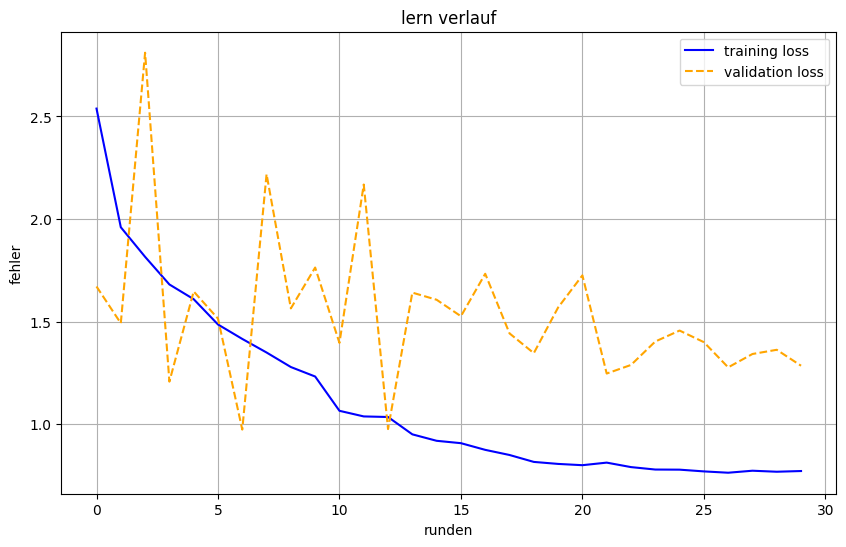

In [17]:
# grafik zeichnen
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='training loss', color='blue')
plt.plot(val_losses, label='validation loss', color='orange', linestyle='--')
plt.title("lern verlauf")
plt.xlabel("runden")
plt.ylabel("fehler")
plt.legend(); plt.grid(True); plt.show()

C:\Users\marvi\AppData\Local\Temp\ipykernel_32976\1116936738.py:57: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\IT\venvs\ml_venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


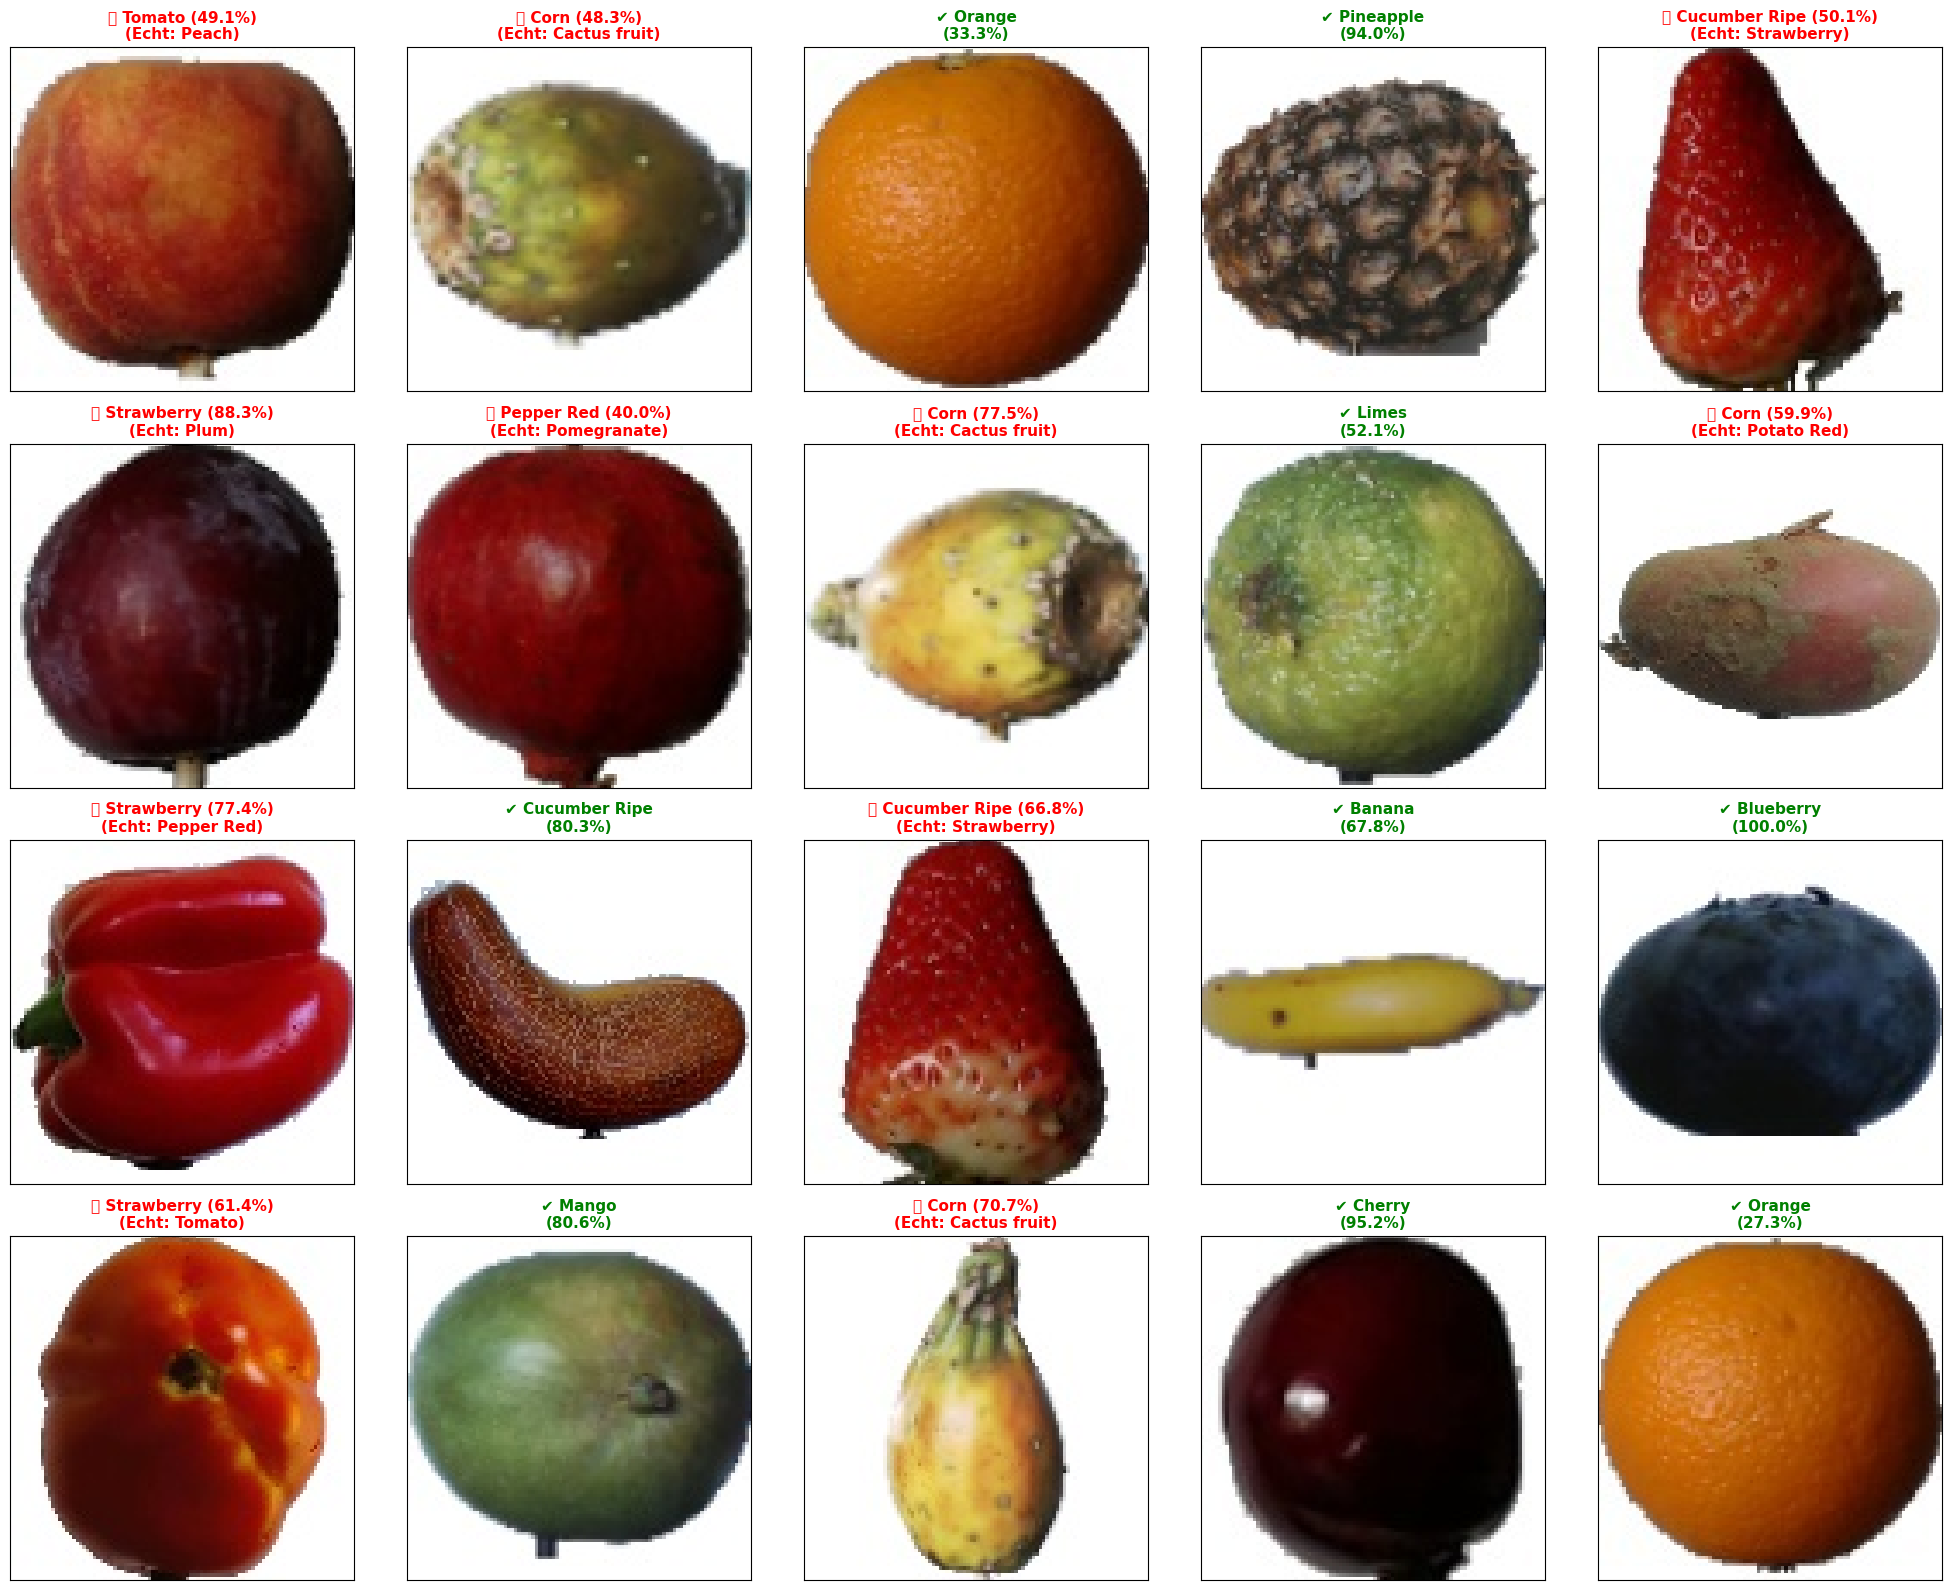

In [23]:

# 1. Wir holen uns einen ganzen Stapel (Batch)
dataiter = iter(val_loader)
images, labels = next(dataiter)

# Ab auf die Grafikkarte damit (oder CPU)
images = images.to(DEVICE)
labels = labels.to(DEVICE)

# 2. Modell fragen
model.eval()
with torch.no_grad():
    outputs = model(images)
    probs = F.softmax(outputs, dim=1)      # In % umrechnen
    confidences, predictions = torch.max(probs, 1) # Höchsten Wert nehmen

# 3. Plot vorbereiten (5 Spalten x 4 Zeilen = 20 Bilder)
num_images = 20
rows = 4
cols = 5

fig = plt.figure(figsize=(20, 16)) # Groß genug machen

for i in range(num_images):
    # Falls der Batch kleiner als 20 ist (beim Rest), brechen wir ab
    if i >= len(images):
        break
        
    ax = fig.add_subplot(rows, cols, i+1, xticks=[], yticks=[])
    
    # Bild für Anzeige vorbereiten:
    # A. Von GPU zur CPU
    # B. Format ändern: (Channels, Höhe, Breite) -> (Höhe, Breite, Channels)
    img_display = images[i].cpu().numpy().transpose((1, 2, 0))
    
    # C. "Ent-Normalisieren" (wir hatten es durch 0.5 geteilt, jetzt mal 0.5)
    img_display = img_display * 0.5 + 0.5
    img_display = np.clip(img_display, 0, 1) # Alles was <0 oder >1 ist abschneiden
    
    plt.imshow(img_display)
    
    # Infos holen
    true_label = class_names[labels[i]]
    pred_label = class_names[predictions[i]]
    conf_val = confidences[i].item() * 100
    
    # Farbe: Grün = Richtig, Rot = Falsch
    color = 'green' if true_label == pred_label else 'red'
    
    # Titeltext bauen
    if true_label == pred_label:
        title_text = f"✔ {pred_label}\n({conf_val:.1f}%)"
    else:
        title_text = f"❌ {pred_label} ({conf_val:.1f}%)\n(Echt: {true_label})"
        
    ax.set_title(title_text, color=color, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

🔎 Teste 8 externe Bilder...


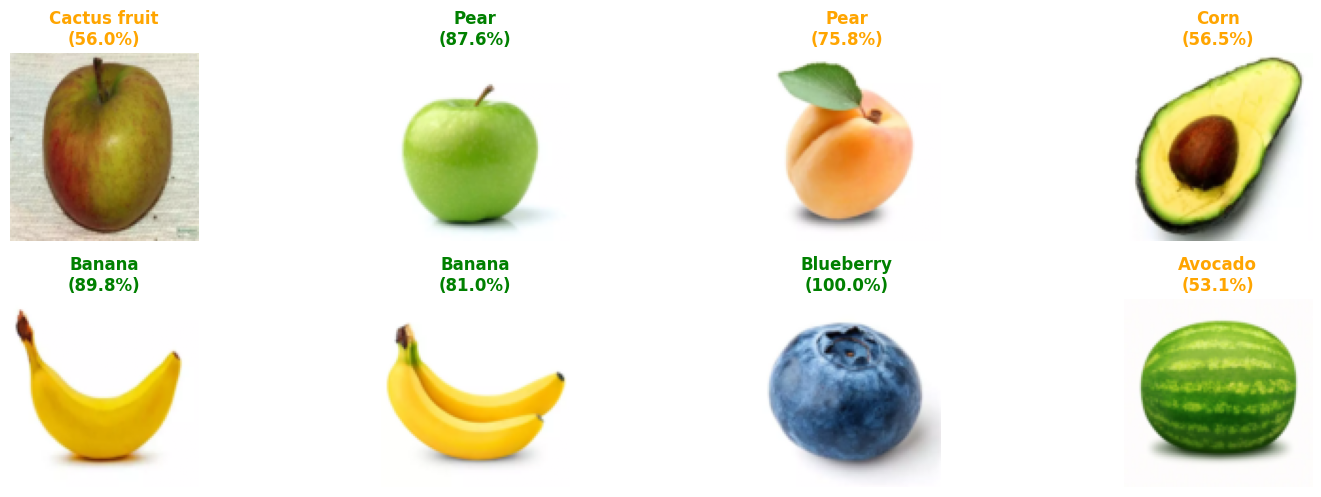

In [20]:
# wo liegen die bilder?
TEST_DIR = "./downloads" 
IMG_SIZE = 100 

# wir müssen die bilder genau so behandeln wie im training (clean_transforms)
custom_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# alle bilder aus dem ordner laden
image_files = [f for f in os.listdir(TEST_DIR) if f.endswith(('.jpg', '.jpeg', '.png'))]

if len(image_files) == 0:
    print(f"❌ Keine Bilder in '{TEST_DIR}' gefunden! Bitte Pfad prüfen.")
else:
    print(f"🔎 Teste {len(image_files)} externe Bilder...")

    plt.figure(figsize=(15, 10))
    model.eval() # prüfungs-modus

    for i, img_name in enumerate(image_files):
        try:
            # 1. bild laden
            img_path = os.path.join(TEST_DIR, img_name)
            image = Image.open(img_path).convert('RGB')
            
            # 2. bild vorbereiten
            input_tensor = custom_transform(image).unsqueeze(0).to(DEVICE)
            
            # 3. vorhersage
            with torch.no_grad():
                outputs = model(input_tensor)
                probs = F.softmax(outputs, dim=1) # Jetzt kennt er F!
                conf, pred_idx = torch.max(probs, 1)
            
            # 4. ergebnis anzeigen
            predicted_class = class_names[pred_idx.item()]
            confidence = conf.item() * 100
            
            ax = plt.subplot(4, 4, i+1)
            
            # anzeigen
            img_display = input_tensor.squeeze(0).cpu().permute(1, 2, 0).numpy()
            img_display = img_display * 0.5 + 0.5
            img_display = np.clip(img_display, 0, 1)
            
            plt.imshow(img_display)
            plt.axis('off')
            
            title_color = 'green' if confidence > 80 else 'orange'
            if confidence < 40: title_color = 'red'
                
            plt.title(f"{predicted_class}\n({confidence:.1f}%)", 
                      color=title_color, fontsize=12, fontweight='bold')
                      
        except Exception as e:
            print(f"Fehler bei Bild {img_name}: {e}")

    plt.tight_layout()
    plt.show()